In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import statsmodels.api as sm

In [2]:


data = pd.read_csv('Preços_de_casas.csv')

Precificação valores de um casa utilizando regressão linear.
Utilizaremos conceitos de amostragem de dados e análise exploratória de dados.
Identificar como como algumas variáveis influenciam no valor de venda de uma casa.

In [3]:
# Quais são os fatores que foram coletados a partir dos dados carregadO?
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1438 entries, 0 to 1437
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Id                              1438 non-null   int64  
 1   area_primeiro_andar             1438 non-null   float64
 2   existe_segundo_andar            1438 non-null   int64  
 3   area_segundo_andar              1438 non-null   float64
 4   quantidade_banheiros            1438 non-null   int64  
 5   capacidade_carros_garagem       1438 non-null   int64  
 6   qualidade_da_cozinha_Excelente  1438 non-null   int64  
 7   preco_de_venda                  1438 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 90.0 KB


In [4]:
data = data.drop(columns='Id')

In [5]:
# correlação dos vatores

corr = data.corr()

Intensidade: Refere-se à força da relação entre as variáveis medidas. 

- Pode variar de -1 a +1, onde -1 indica uma correlação perfeitamente negativa, +1 indica uma correlação perfeitamente positiva e 0 indica ausência de correlação linear.

        
Direção: Refere-se à natureza da relação entre as variáveis medidas. 

- Uma correlação positiva indica que as variáveis aumentam ou diminuem juntas. 
        
- Uma correlação negativa indica que uma variável aumenta enquanto a outra diminui, ou vice-versa.

In [6]:
# Para cada uma das colunas do conjunto, iremos retornar a correlação com a coluna de "preço de venda"
# quanto mais próximo dos extremos, mais correlacionado as variáveis estão com a variável analisada
#
corr['preco_de_venda']

area_primeiro_andar               0.616557
existe_segundo_andar              0.138541
area_segundo_andar                0.305311
quantidade_banheiros              0.563132
capacidade_carros_garagem         0.640214
qualidade_da_cozinha_Excelente    0.496223
preco_de_venda                    1.000000
Name: preco_de_venda, dtype: float64

Analizando o coeficiente de correlação linear entre as variáveis "capacidade_carros_garagem" e "preco_de_venda":

- Intensidade: O coeficiente de correlação linear é de 0.64, indicando uma correlação moderadamente forte; 

- direção: No geral, a medida que a capacidade de carros da garagem de uma casa aumenta, seu preço também tende a aumentar 

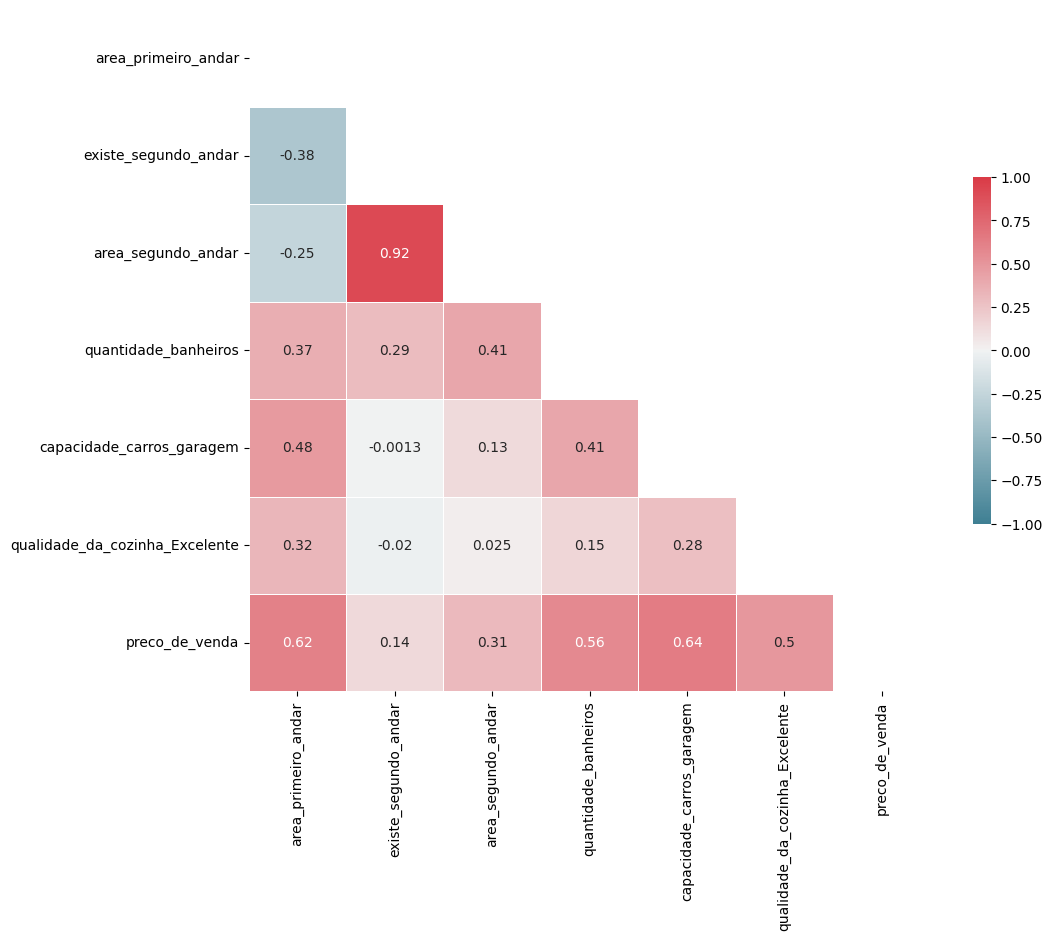

In [7]:
# Gerar uma máscara para o triângulo superior
mascara = np.zeros_like(corr, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

# Configurar a figura do matplotlib
f, ax = plt.subplots(figsize=(11, 9))

# Gerar o mapa de calor (heatmap)
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, mask=mascara, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=True, cbar_kws={"shrink": .5})

# Exibir o mapa de calor (heatmap)
plt.show()

In [8]:
%pip install plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Text(0, 0.5, 'Preço de venda')

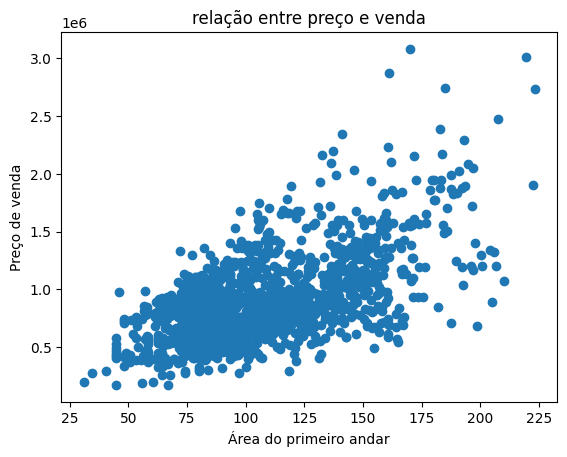

In [9]:
# aparentemente, quanto maior a area do primeiro andar, maior é o preço da casa.

plt.scatter(x = data['area_primeiro_andar'], y = data ['preco_de_venda'])

plt.title("relação entre preço e venda")
plt.xlabel("Área do primeiro andar")
plt.ylabel("Preço de venda")


Text(0, 0.5, 'Preço de venda')

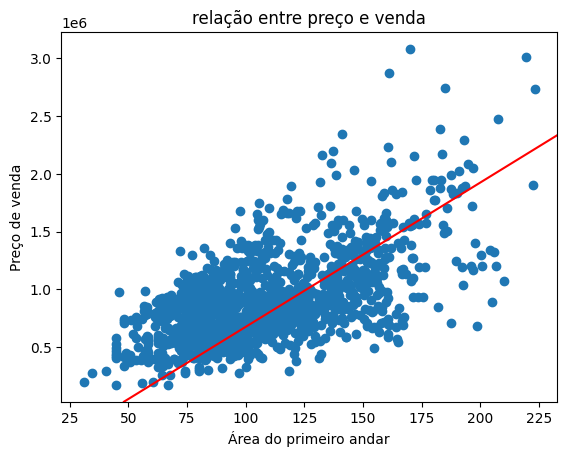

In [10]:
plt.scatter(x = data['area_primeiro_andar'], y = data ['preco_de_venda'])

# Abaixo traças uma linha através da marcação de dois pontos no gráfico, utilizando as coordenadas x e y.
# Os valores atribuídos são arbitrários e, nesse caso, são utilizados para analizar esses pontos
plt.axline(xy1 = (66,250000), xy2= (190, 1800000), color = "red")

plt.title("relação entre preço e venda")
plt.xlabel("Área do primeiro andar")
plt.ylabel("Preço de venda")

In [11]:
# Qual é a melhor reta que representa os meus dados?

px.scatter(data, x = "area_primeiro_andar", y = 'preco_de_venda', trendline_color_override= 'red', trendline= 'ols')

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': 'area_primeiro_andar=%{x}<br>preco_de_venda=%{y}<extra></extra>',
              'legendgroup': '',
              'marker': {'color': '#636efa', 'symbol': 'circle'},
              'mode': 'markers',
              'name': '',
              'showlegend': False,
              'type': 'scattergl',
              'x': array([ 79.5224, 117.2398,  85.468 , ..., 110.3652, 100.1462, 116.6824],
                         shape=(1438,)),
              'xaxis': 'x',
              'y': array([1027905.  ,  894795.  , 1101855.  , ..., 1313845.  ,  700676.25,
                           727175.  ], shape=(1438,)),
              'yaxis': 'y'},
             {'hovertemplate': ('<b>OLS trendline</b><br>preco_' ... ' <b>(trend)</b><extra></extra>'),
              'legendgroup': '',
              'line': {'color': 'red'},
              'marker': {'color': '#636efa', 'symbol': 'circle'},
              'mode': 'lines',
              'name': '',
              'showlegend': False,
              'type': 'scattergl',
              'x': array([ 31.0286,  34.5588,  40.6902, ..., 219.6156, 222.2168, 223.1458],
                         shape=(1438,)),
              'xaxis': 'x',
              'y': array([ 358849.30911813,  383204.85024705,  425506.57957624, ...,
                          1659947.95363708, 1677894.14183734, 1684303.49476601], shape=(1438,)),
              'yaxis': 'y'}],
    'layout': {'legend': {'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'area_primeiro_andar'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'preco_de_venda'}}}
})

-  Elencamos uma variável explicativa
- Elencamos uma variável 
- a representação linear possuyi uma formula que é Yi = Bo + B1*Xi
- Com isso, podemos definir o preço de venda a partir da área do primeiro andar

O QUE APRENDI ATÉ AQUI:
- Obter o coeficiente de correlação dos dados;
- Analisar a intensidade e a direção da correlação entre duas variáveis;
- Identificar linearidade no gráfico de dispersão;
- Diferenciar variável explicativa de variável resposta;
- Visualizar a melhor reta utilizando o Plotly.

## Explicando a reta 

Ajustamos uma reta entre o metro quadrado do primeiro andar e o preço da casa. Queremos explicar o preço da casa a partir do seu tamanho, por isso, dizemos que:

- Variável explicativa/independente: Área do primeiro andar;
- Variável resposta/dependente: Preço da casa


#### Separando em treino e teste

O conjunto de **treinamento** é usado para ajustar modelos de ML. o conjunto de **Teste** é usado para avaliar a acurávia do algorítmo em prever o preço de venda de casas oriundas de um novo conjunto de dados.

In [12]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [13]:
# import train test split

from sklearn.model_selection import train_test_split


In [14]:
y = data['preco_de_venda']
x = data.drop(columns='preco_de_venda')

In [15]:
# criando a separação entre o treino e teste
# o train_test_split retorna 4 variáveis.

x_train, x_test, y_train, y_teste = train_test_split(x, y, test_size = 0.3, random_state=230 )

In [16]:
df_train = pd.DataFrame(data = x_train)
df_train['preco_de_venda'] = y_train


In [17]:
from statsmodels.formula.api import ols

In [18]:
modelo_0 = ols('preco_de_venda ~ area_primeiro_andar', data = df_train).fit()

#### Analisando os coeficientes

Intencidade, direção e signfiicância

In [19]:
# Visualização os parâmetros
# se a área da casa for zero e ainda nao foi construída, identificamos que o preço dela em média será o da variável intercept retornada pela função abaixo


modelo_0.params

Intercept              152909.288334
area_primeiro_andar      6793.641641
dtype: float64

In [20]:
# Acessando o resumno do modelo

print(modelo_0.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     608.3
Date:                Thu, 26 Dec 2024   Prob (F-statistic):          2.22e-105
Time:                        22:13:06   Log-Likelihood:                -14082.
No. Observations:                1006   AIC:                         2.817e+04
Df Residuals:                    1004   BIC:                         2.818e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1.529e+05   3

##### A regressão linear foi a metodologia que ajustou a melhor reta que representa linearmente a interação entre X e Y; no nosso caso, o tamanho da área do primeiro andar e o preço de venda da casa.

##### Y = β₀ + (β₁).(x) + e

- **Variável Resposta (Y)**: Também chamada de variável dependente é aquela que estamos tentando prever.

- **Intercepto (β₀)**: O ponto onde a linha de regressão intercepta o eixo vertical (Y), ou seja, o valor de Y quando X é igual a 0.

- **Variável Explicativa (X)**: Também chamada de variável independente e é o fator que usamos para prever e explicar a variável resposta.

- **Coeficientes de Regressão (β₁)**: Impacto de cada variável explicativa X na variável resposta, é o efeito de X em Y.

- **Erro Residual (e)**: Diferença entre os valores reais e previstos da variável resposta.

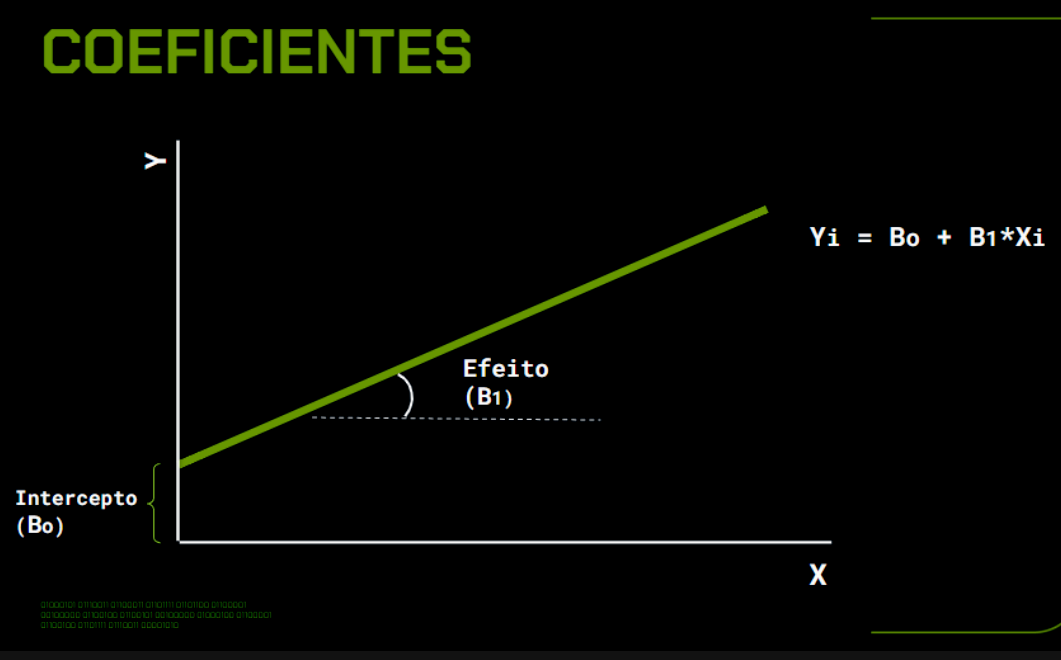

##### Será que ometro quadrado é suficiente para explicar o preço da casa?

Precisamos recorrer a variável R², o coeficiente de **determinação**. O R² varia de 0 a 1, onde 1 indica que um ajuste perfeito no modelo de dados, ou seja, todas as variações na variável dependente são explicadas pelas variáveis indeptendentes do modelo.

Se o R² está em zero, isso indica que o modelo não explica nanhuma variabiabilidade na variável independente.

In [21]:
# Nesse caso, um R² próximo de 0 indica que somente a variável x, área da casa, não explica tototalmente a variável preço de venda, que é o y da função
modelo_0.rsquared

np.float64(0.3772801099429788)

##### Entendendo o Resíduo

Os residuos são a a diferenca entre a reta traçada pelo modelo (que é uma predição média) e a observação da realidade, isto é, o quão longe a predição está longe dos valores reais.

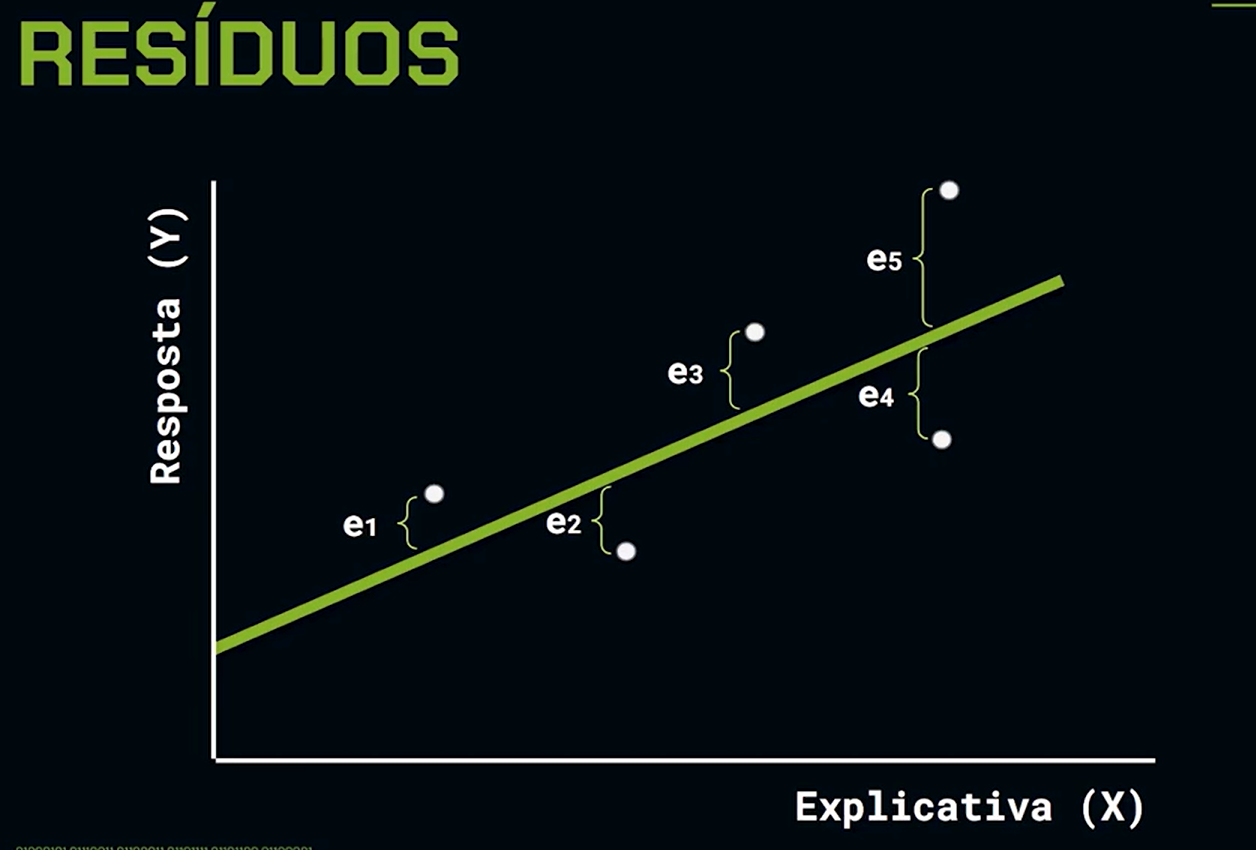

In [22]:
modelo_0.resid

1303   -193023.838744
326    -144522.356193
386     399612.747641
615     -68449.596607
236     166010.592859
            ...      
777     465872.680999
271    -497642.319788
723     461150.204718
560    -540482.733402
768     -37547.820756
Length: 1006, dtype: float64

Text(0.5, 1.0, 'distribuição dos resíduos')

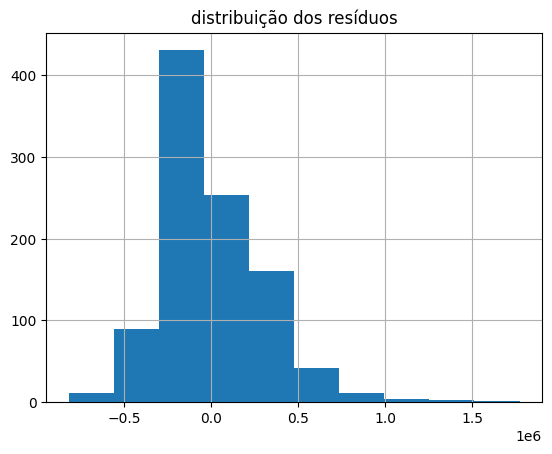

In [23]:
modelo_0.resid.hist()

plt.title("distribuição dos resíduos")

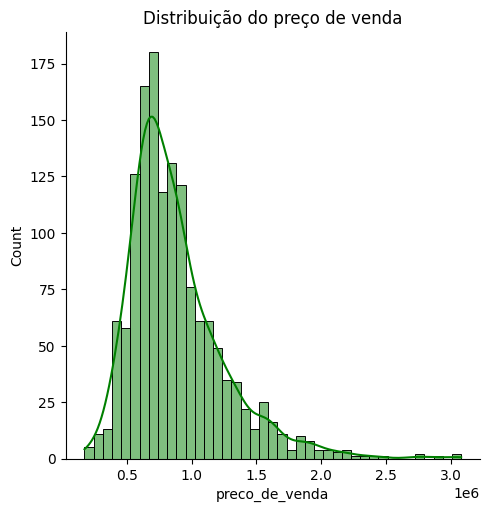

In [24]:
sns.displot(data['preco_de_venda'], kde=True, color='green')
plt.title('Distribuição do preço de venda')
plt.show()


##### Testando a acurácia do modelo

Nesse momento iremos validar a qualidade do modelo de dados medindo a taxa de acerto através da comparação entre os dados previstos e os dados de teste (que são os dados reais).


In [25]:
y_predict = modelo_0.predict(x_test)

In [26]:
from sklearn.metrics import r2_score

É importante que os R² dos dados de treino e o R² score do modelo de dados estejam próximos um do outro. isso indica que uma porcentagem dos preços das casas podem ser explicadas a partir da variável área do primeiro andar

In [27]:
print("R²", r2_score(y_teste,y_predict))

R² 0.38530928723202407


Sintese:

- Dividir a base de dados para treinar e testar o modelo;
- Interpretar os coeficientes de regressão linear simples;
- Calcular e interpretar o coeficiente de determinação R²;
- Analisar o quanto cada ponto de dados desvia da linha de regressão ajustada através dos resíduos;
- Compreender quão bem os valores observados se ajustam ao modelo de regressão com R²;
- Calcular o R² no conjunto teste.

### 3. Analisando outros fatores com pairplot


O modelo criado até o momento demonstrou um R² de 37%, ou seja, aproximadamente 37% dos preços de casas previstos pelo modelo podem ser explicados pela variável da área do primeiro andar. Isso indica que há uma quantidade significativa de variáveis que não foram consideradas no treinamento do modelo de dados, portanto, somente a area do primeiro andar, a unica variação utilizada até o momento, não explica o preço de venda da casa.

#### Analisando os fatores

Através do pairplot, podemos realizar uma análise exploratória para entender o comportamento das variáveis do dataset cruzada com a variável resposta. 

Em outras palavras, precisamos cruzar as variáveis de entrada com as variáveis de saída para entender outras relações de linearidade candidatas existentes no conjunto de dados.

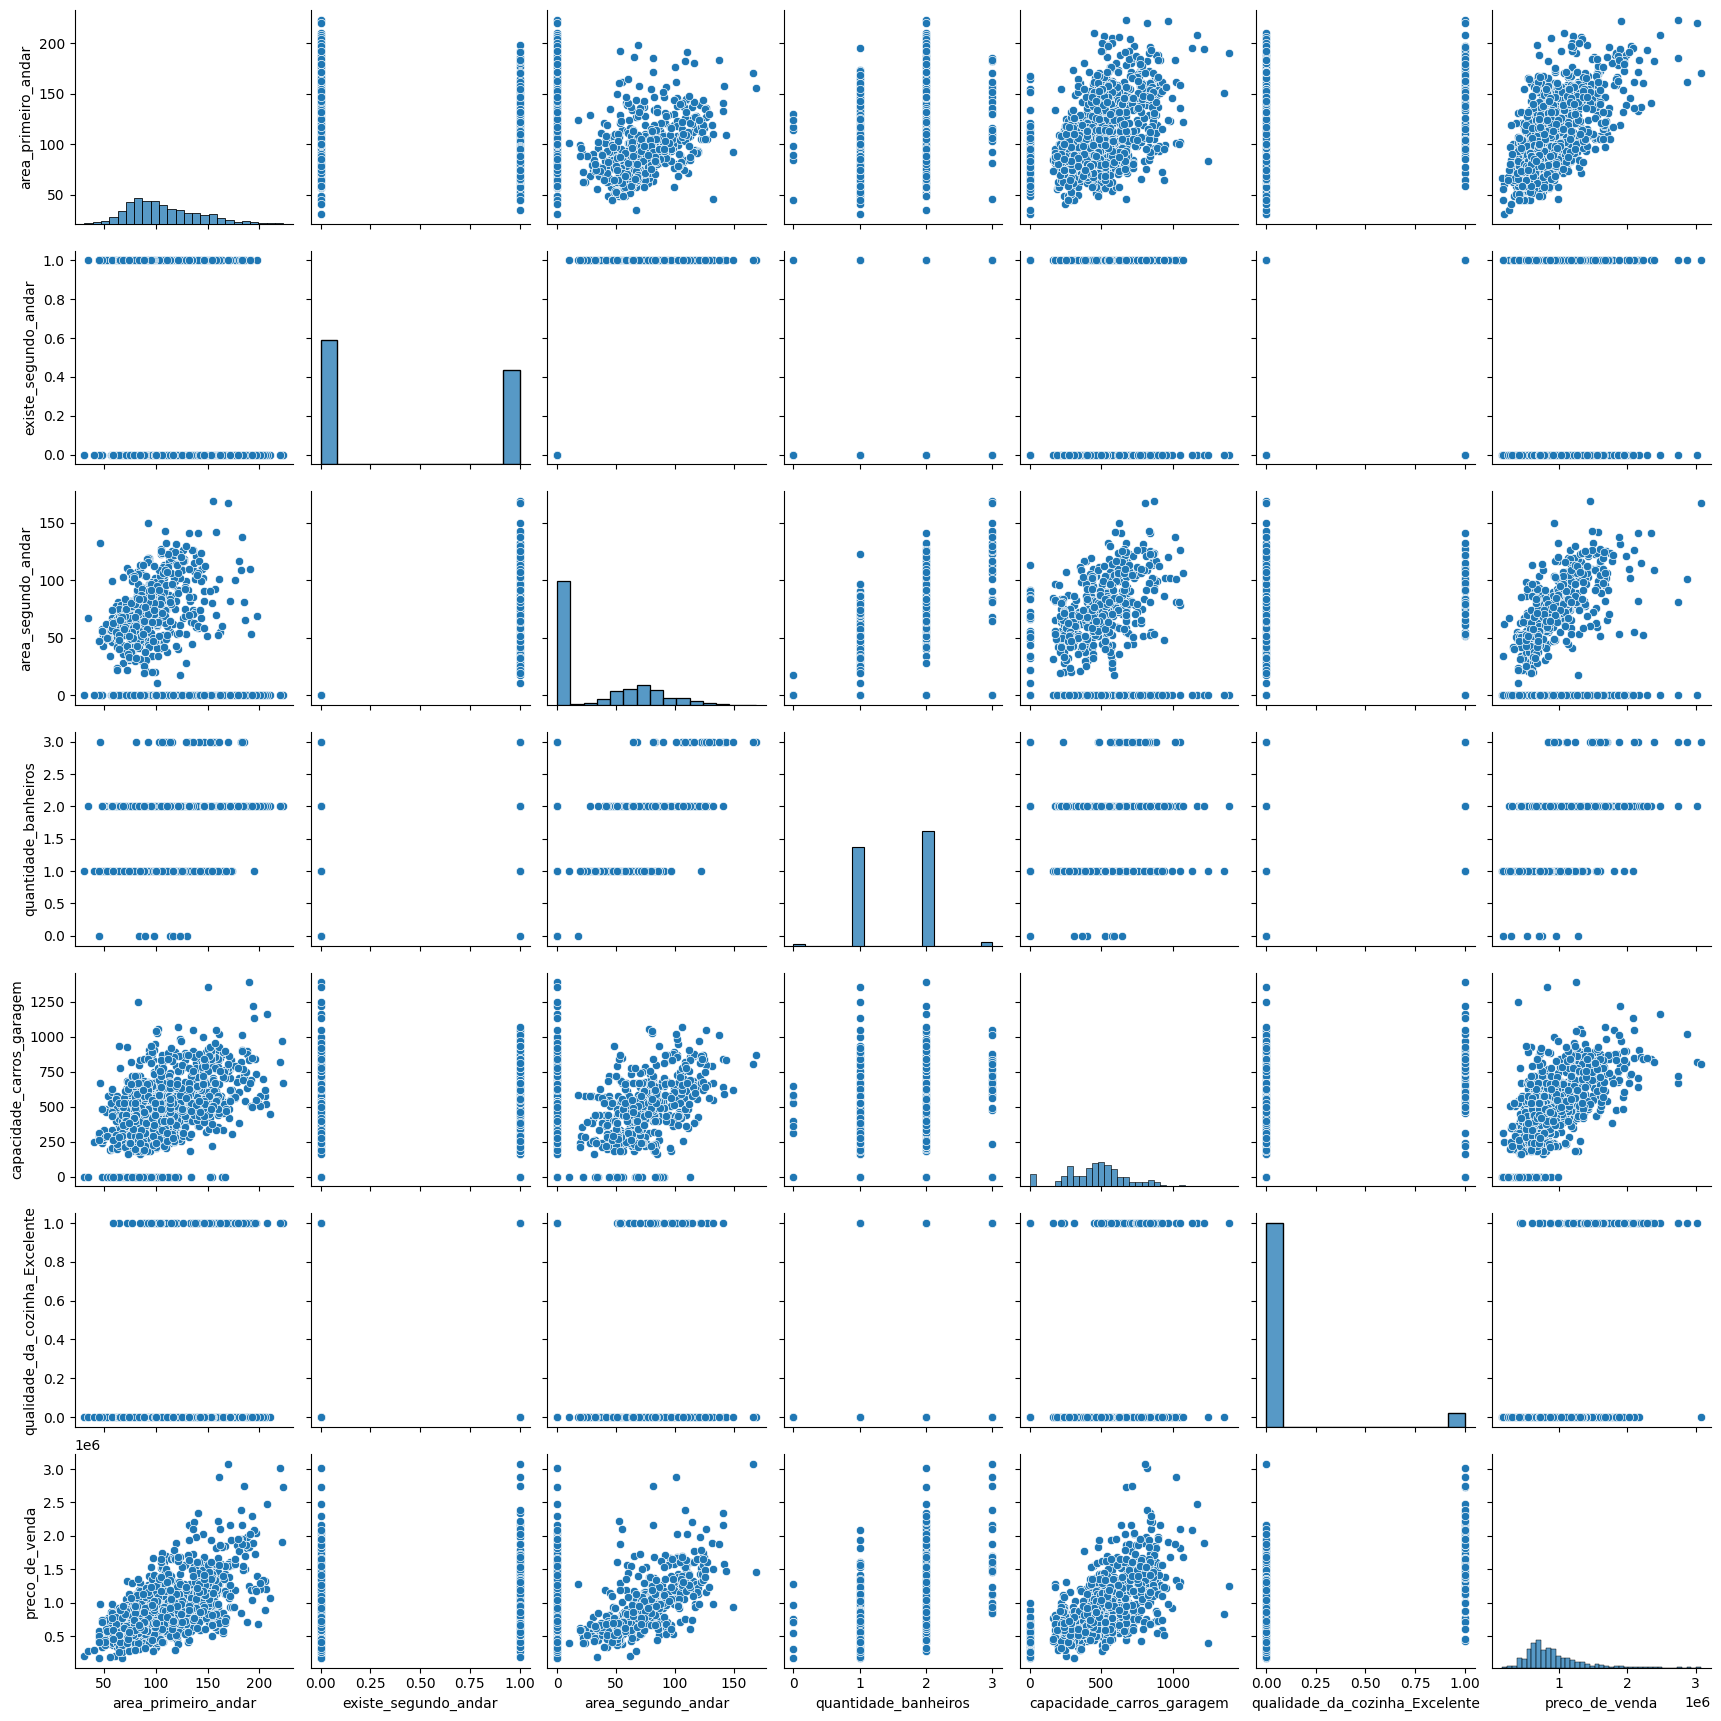

In [28]:
sns.pairplot(data)

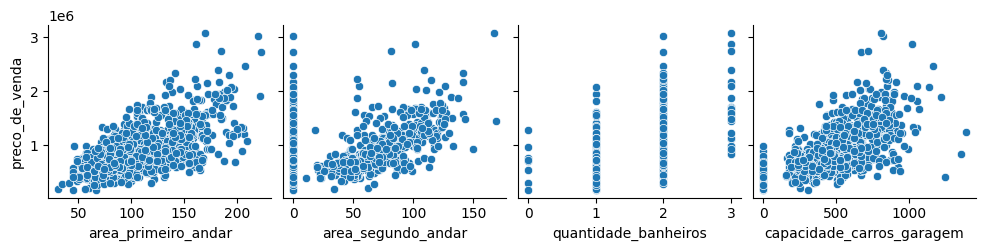

In [29]:
sns.pairplot(data, y_vars='preco_de_venda', x_vars=['area_primeiro_andar','area_segundo_andar','quantidade_banheiros','capacidade_carros_garagem'])



#### Adicionando fatores ao modelo

In [30]:
import statsmodels.api as sm

In [31]:
x_train = sm.add_constant(x_train)

In [32]:
modelo_1 = sm.OLS(y_train,
                  x_train[['const','area_primeiro_andar',"existe_segundo_andar", "area_segundo_andar", 
                          'quantidade_banheiros','capacidade_carros_garagem', 'qualidade_da_cozinha_Excelente']]).fit()

In [33]:
modelo_2 = sm.OLS(y_train,
                  x_train[['const','area_primeiro_andar',"existe_segundo_andar", 
                          'quantidade_banheiros','capacidade_carros_garagem', 'qualidade_da_cozinha_Excelente']]).fit()

In [34]:
modelo_3 = sm.OLS(y_train,
                  x_train[['const','area_primeiro_andar',"existe_segundo_andar", 
                          'quantidade_banheiros', 'qualidade_da_cozinha_Excelente']]).fit()

In [35]:
print(modelo_1.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     477.4
Date:                Thu, 26 Dec 2024   Prob (F-statistic):          2.79e-289
Time:                        22:13:11   Log-Likelihood:                -13640.
No. Observations:                1006   AIC:                         2.729e+04
Df Residuals:                     999   BIC:                         2.733e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [36]:
print(modelo_2.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     485.3
Date:                Thu, 26 Dec 2024   Prob (F-statistic):          1.93e-264
Time:                        22:13:11   Log-Likelihood:                -13701.
No. Observations:                1006   AIC:                         2.741e+04
Df Residuals:                    1000   BIC:                         2.744e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [37]:
print(modelo_3.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     467.1
Date:                Thu, 26 Dec 2024   Prob (F-statistic):          4.15e-227
Time:                        22:13:11   Log-Likelihood:                -13790.
No. Observations:                1006   AIC:                         2.759e+04
Df Residuals:                    1001   BIC:                         2.762e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

### Comparando modelos

In [38]:
print("modelo 0: ", modelo_0.rsquared)
print("modelo 1: ", modelo_1.rsquared)
print("modelo 2: ", modelo_2.rsquared)
print("modelo 3: ", modelo_3.rsquared)


modelo 0:  0.3772801099429788
modelo 1:  0.7414024156090393
modelo 2:  0.7081440416220739
modelo 3:  0.6511289354898803


Há uma relação entre quantidade de parametros e o preço de venda da casa, porém, algumas podem ter efeitos negativos, por exemplo, quando incluímos a area do segundo andar e se existe segundo andar. Isso satura o modelo e pode gerar um efeito de confusão.


métodos, como stepwise, backward e forward selection, seguem critérios pré-definidos para adicionar ou remover variáveis do modelo de forma iterativa. Explore a seguir os métodos automáticos de seleção de variáveis, que visam equilibrar a complexidade do modelo e sua capacidade explicativa.

- O método forward selection começa com um modelo sem variáveis explicativas e adiciona uma a uma, escolhendo em cada passo a variável que mais melhora o modelo de acordo com um critério estatístico específico, como o menor valor de p-valor ou o maior aumento no R² ajustado.
- O backward selection inicia com todas as variáveis possíveis no modelo e, iterativamente, remove a variável que menos contribui para o modelo, novamente baseando-se em critérios como o p-valor ou o impacto no R² ajustado.
- O stepwise selection é uma combinação dos dois métodos anteriores, onde as variáveis podem ser adicionadas ou removidas em cada passo, dependendo de sua contribuição para o melhoramento do modelo.


Esses métodos de seleção automática são ferramentas poderosas que ajudam na identificação do modelo mais parcimonioso, ou seja, aquele que consegue explicar os dados de maneira eficiente sem ser excessivamente complexo. Contudo, é crucial que o cientista de dados compreenda e supervisione o processo, pois a escolha automática pode, às vezes, introduzir viés ou sobreajuste, especialmente se o critério de seleção não for bem escolhido ou se o modelo não for validado adequadamente com dados novos ou de teste.



In [39]:
# Qualtos parâmetros estão no modelo?
print(len(modelo_0.params))
print(len(modelo_1.params))
print(len(modelo_2.params))
print(len(modelo_3.params))


2
7
6
5


In [40]:
modelo_3.params

const                            -129979.678094
area_primeiro_andar                 6119.653184
existe_segundo_andar              221306.959705
quantidade_banheiros              149036.289458
qualidade_da_cozinha_Excelente    444391.228573
dtype: float64

#### Estudado até aqui

- Utilizar o pairplot do Seaborn para visualizar relações entre múltiplas variáveis e identificar quais podem influenciar o preço de venda das casas.
- Adicionar múltiplas variáveis explicativas ao modelo de regressão linear para aprimorar a precisão das previsões de preço.
- Comparar diferentes modelos de regressão linear utilizando o R² e o R² ajustado, além de analisar a multicolinearidade e outros fatores.
- Descobrir como interpretar os coeficientes do modelo de regressão linear para entender o impacto de cada variável no preço das casas.
- Entender a importância de escolher o modelo mais adequado para previsão de preços, considerando a simplicidade, a precisão e a interpretabilidade.

### Precificando uma casa

#### Obtendo o R² da previsão

In [45]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 432 entries, 997 to 185
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   const                           432 non-null    float64
 1   area_primeiro_andar             432 non-null    float64
 2   existe_segundo_andar            432 non-null    int64  
 3   area_segundo_andar              432 non-null    float64
 4   quantidade_banheiros            432 non-null    int64  
 5   capacidade_carros_garagem       432 non-null    int64  
 6   qualidade_da_cozinha_Excelente  432 non-null    int64  
dtypes: float64(3), int64(4)
memory usage: 27.0 KB


In [46]:
modelo_3.params

const                            -129979.678094
area_primeiro_andar                 6119.653184
existe_segundo_andar              221306.959705
quantidade_banheiros              149036.289458
qualidade_da_cozinha_Excelente    444391.228573
dtype: float64

In [44]:
# Adicionando uma constante em X_test
x_test = sm.add_constant(x_test)

In [50]:
# Prevendo com o modelo 3
predict_3 = modelo_3.predict(x_test[["const","area_primeiro_andar","existe_segundo_andar","quantidade_banheiros","qualidade_da_cozinha_Excelente"]])

In [53]:
# Qual o r² da previsão?
modelo_3.rsquared

np.float64(0.6511289354898803)

In [54]:
# Qual o R² do treino?

print('R²: ', r2_score(y_teste, predict_3))

R²:  0.6432078074497707


## Precificando uma casa


<img src="https://i.imgur.com/e4gytI1.png" width="800"/>

In [56]:
modelo_3.params

const                            -129979.678094
area_primeiro_andar                 6119.653184
existe_segundo_andar              221306.959705
quantidade_banheiros              149036.289458
qualidade_da_cozinha_Excelente    444391.228573
dtype: float64

In [65]:
#Novo imovel

nova_casa = pd.DataFrame({
    "const" : [1], 
    "area_primeiro_andar": [120],
    "existe_segundo_andar": [1], 
    "quantidade_banheiros": [2],
    "qualidade_da_cozinha_Excelente":[0]    
})

In [68]:
# Qual o preço desse imóvel com o modelo 0?
modelo_0.predict(nova_casa["area_primeiro_andar"])

0    968146.285305
dtype: float64

In [70]:
# Qual o preço desse imóvel com o modelo 3?
print(modelo_3.predict(nova_casa)[0])

1123758.2426020517


## Precificando várias casas

<img src="https://i.imgur.com/i0skFlB.jpeg" width="600"/>

In [78]:
# Lendo várias casas?
novos_imoveis = pd.read_csv('Novas_casas.csv', sep=";")

In [93]:
novos_imoveis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   const                           10 non-null     float64
 1   area_primeiro_andar             10 non-null     int64  
 2   existe_segundo_andar            10 non-null     int64  
 3   quantidade_banheiros            10 non-null     int64  
 4   qualidade_da_cozinha_Excelente  10 non-null     int64  
dtypes: float64(1), int64(4)
memory usage: 532.0 bytes


In [86]:
# Adicionando uma constante
novos_imoveis = sm.add_constant(novos_imoveis)

In [92]:
novos_imoveis = novos_imoveis.drop(columns="Casa")

In [94]:
# Qual o preço dessas novas casas?
modelo_3.predict(novos_imoveis)

0    1.751739e+06
1    1.863058e+06
2    1.568149e+06
3    2.206758e+06
4    1.591629e+06
5    1.246151e+06
6    1.357470e+06
7    1.552134e+06
8    9.636478e+05
9    1.639974e+06
dtype: float64

In [95]:
imovel_2 = pd.DataFrame({
    "const" : [1],
    "area_primeiro_andar" : [98],
    "existe_segundo_andar" : [0],
    "quantidade_banheiros" : [1],
    "qualidade_da_cozinha_Excelente" : [1],
})

In [97]:
print(modelo_3.predict(imovel_2)[0])

1063173.8519646404


### Salvando o modelo em um arquivo

Ao desenvolver modelos de regressão com Statsmodels, é comum querer salvar esses modelos para uso futuro, seja para implantação em produção, compartilhamento com outros membros da equipe ou simplesmente para backup. Uma maneira conveniente de fazer isso em Python é usando a biblioteca pickle, que permite serializar objetos Python em arquivos e desserializá-los de volta para objetos Python. Essa biblioteca não precisa ser instalada, uma vez que já vem por padrão no Python.

In [100]:
import pickle

# Nome do arquivo onde o modelo será salvo
nome_arquivo = 'modelo_regressao_linear.pkl'

# Salvar o modelo em um arquivo usando pickle
with open(nome_arquivo, 'wb') as arquivo:
    pickle.dump(modelo_3, arquivo)

In [ ]:
# Carregar o modelo de volta do arquivo
with open(nome_arquivo, 'rb') as arquivo:
    modelo_carregado = pickle.load(arquivo)

#### Aprendizado até aqui

- Obter a métrica R² do modelo a partir de dados de teste;
- Entender a importância da comparação de métricas de treino e teste para checar a generalização do modelo;
- Utilizar o método predict para realizar a previsão de novos valores a partir de um modelo de regressão;
- Salvar um modelo de machine learning utilizando a biblioteca pickle;
- Fazer a leitura de arquivos pickle para obter o modelo em seu estado original.

# 5. Investigando o modelo





## Multicolinearidade


Quando duas ou mais coisas que você está tentando estudar são tão parecidas que é difícil dizer o quanto cada uma delas está influenciando o resultado.